In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

Matplotlib is building the font cache; this may take a moment.


In [3]:
data = fetch_california_housing(as_frame=True)

df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

In [4]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [7]:
tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [11]:
train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 3.218325866275131e-16
Test RMSE: 0.7030445773467542


In [12]:
cv_scores = cross_val_score(
    tree,
    X_scaled,
    y,
    scoring="neg_mean_squared_error",
    cv=5
)

cv_rmse = np.sqrt(-cv_scores.mean())

print("Cross Validation RMSE:", cv_rmse)

Cross Validation RMSE: 0.8965606692892136


In [13]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_mean_squared_error",
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10}


In [14]:
best_tree = grid.best_estimator_

y_pred_tree = best_tree.predict(X_test)

tree_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
tree_r2 = r2_score(y_test, y_pred_tree)

print("Tuned Decision Tree RMSE:", tree_rmse)
print("Tuned Decision Tree R2:", tree_r2)

Tuned Decision Tree RMSE: 0.6454300828015771
Tuned Decision Tree R2: 0.6820992539714815


In [16]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression RMSE: 0.7455813830127764
Linear Regression R2: 0.5757877060324508


In [17]:
ridge = Ridge()

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge RMSE:", ridge_rmse)
print("Ridge R2:", ridge_r2)

Ridge RMSE: 0.7455542909384612
Ridge R2: 0.5758185345441319


In [18]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Tuned Decision Tree"],
    "RMSE": [lr_rmse, ridge_rmse, tree_rmse],
    "R2 Score": [lr_r2, ridge_r2, tree_r2]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Tuned Decision Tree,0.645430,0.682099


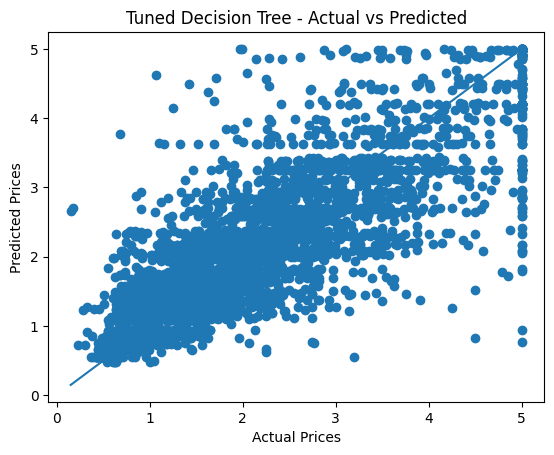

In [19]:
plt.scatter(y_test, y_pred_tree)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Tuned Decision Tree - Actual vs Predicted")

plt.show()

The Decision Tree model initially showed signs of overfitting because
the training RMSE was much lower than the test RMSE.

To control overfitting, hyperparameter tuning was performed using
GridSearchCV. The tuned Decision Tree achieved improved generalization
performance.

After comparing models using RMSE and R² score, the best model was
selected based on its balanced performance.